In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import pretty_midi as pm
import matplotlib.pyplot as plt

from ast import literal_eval

In [5]:
path_data = '../data/apm/'
available_genres = os.listdir(path_data)

genres_of_interest = ['Classical', 'Blues', 'Rock', 'Soul', 'Jazz', 'Latin', 'Pop', 'Country', 'Folk', 'World']
all([genre in available_genres for genre in genres_of_interest])

True

Visualize piece duration distribution per genre.

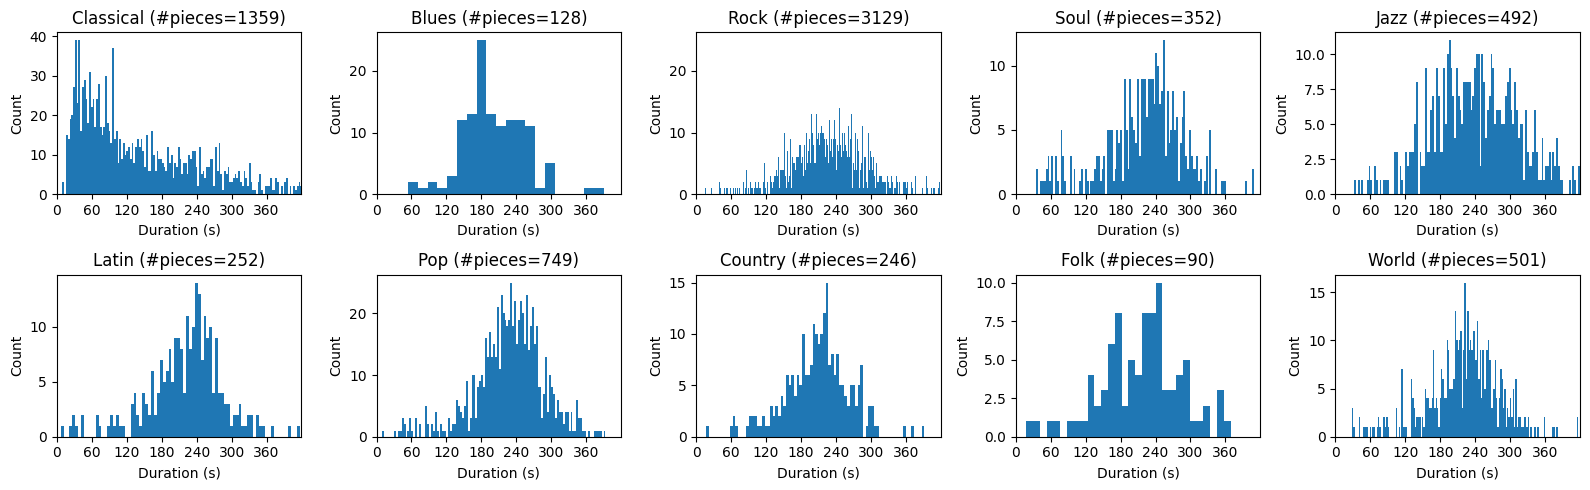

In [7]:
fig, axs = plt.subplots(2, 5, figsize=(16, 5), sharex=False, sharey=False, layout='tight')

for i, genre in enumerate(genres_of_interest):
    path_genre = os.path.join(path_data, genre)
    df = pd.read_csv(f'{path_genre}.csv')
    df['duration'].plot.hist(
        bins=df.shape[0]//3, ax=axs[i//5,i%5], xlim=[0, 7*60], grid=False, xticks=[i*60 for i in range(7)],
        xlabel='Duration (s)', ylabel='Count', title=f'{genre} (#pieces={df.shape[0]})')

Visualize the piece duration distribution per genre **AFTER FILTERING**.

In [8]:
# hardcoded blacklist for reproducibility -- weird pieces with spike-y velocity histograms and low representativeness of their genre -- excluded
blacklist = [
    '../data/apm/Soul/Classic Soul/The Elgins/In The Midnight Hour.mid',
    '../data/apm/Soul/Chicago Soul/The Esquires/Groovin.mid',
    '../data/apm/Soul/Soul/Aaron Neville/Jesus Love Me.mid',
    '../data/apm/Pop/Classic Italian Pop/Edoardo Vianello/Abbronzatissima.mid',
    '../data/apm/Country/Country Gospel/Cristy Lane/Silent Night.mid',
    '../data/apm/Rock/Dance Rock/George Michael/Last Christmas.mid',
    '../data/apm/Rock/Classic Finnish Rock/Heikki Silvennoinen/Down Hearted Man.mid',
    '../data/apm/Rock/Australian Rock/Graeme Connors/Id Rather Be Sorry.mid',
    '../data/apm/Rock/Neo Mellow/Jasmine/Per Non Perderti.mid',
    '../data/apm/Rock/Modern Rock/The Band/As Long As You Love Me.mid'
    ]

### Figure 3

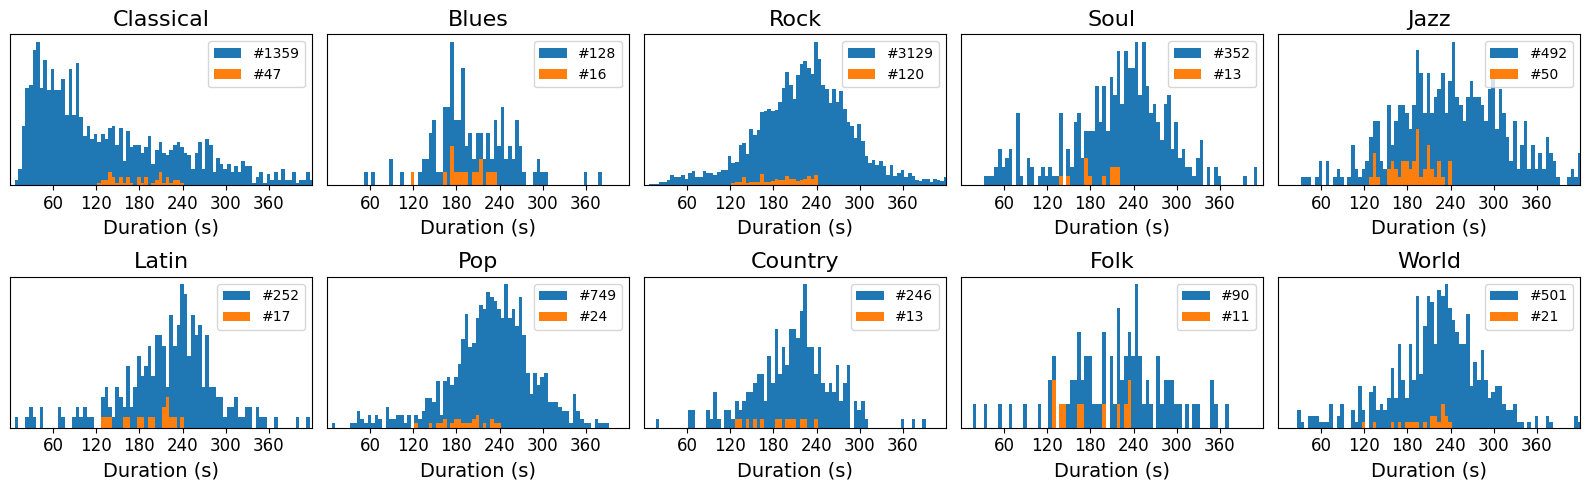

In [9]:
fig, axs = plt.subplots(2, 5, figsize=(16, 5), sharex=False, sharey=False, layout='tight')

fs_title=16
fs_axis=14
fs_ticks=12

# use the same bins for all 10 subplots?
df = pd.read_csv('../data/apm/Latin.csv')
bins = np.histogram_bin_edges(df['duration'], bins=df.shape[0] // 3)

for i, genre in enumerate(genres_of_interest):
    path_genre = os.path.join(path_data, genre)
    df = pd.read_csv(f'{path_genre}.csv')
    
    # Plot before filtering
    df['duration'].plot.hist(
        bins=bins,
        ax=axs[i // 5, i % 5],
        xlim=[0, 7 * 60],
        xticks=[i * 60 for i in range(7)],
        label=f'#{df.shape[0]}',
        # legend=True,
        # xlabel='Duration (s)', ylabel='Count', title=f'{genre}'
    )

    df = df[(df['duration'] >= 2*60) & (df['duration'] <= 4*60)]
    df = df[df['gaps_max'] <= 5]
    df = df[df['num_uniq_velocities'] >= 20]
    df = df[df['num_uniq_pitches'] >= 15]
    df = df[df['num_overlaps'] <= 100] # maybe relax this one later
    df = df[df['num_uniq_cc_nums'] <= 20]
    df = df[df['instr_programs'].apply(lambda x: np.all(np.unique(literal_eval(x)) < 8))] # only piano instruments
    df = df[df['num_bends'].apply(lambda x: sum(literal_eval(x)) == 0)] # no pitch bends
    if genre != 'Folk':
        df = df[df['mean_polyphony'] >= 3.0]
    df = df[df['path'].apply(lambda path: path not in blacklist)]

    # Plot after filtering using the same bins
    df['duration'].plot.hist(
        bins=bins,
        ax=axs[i // 5, i % 5],
        # log=True,
        xlim=[0, 7 * 60],
        xticks=[i * 60 for i in range(1, 4 + 3, 1)],
        label=f'#{df.shape[0]}',
        # legend=True,
        xlabel='Duration (s)',
        # ylabel='Count',
        title=f'{genre}'
    )
    axs[i // 5, i % 5].legend(loc='upper right')  # Set legend position
    axs[i // 5, i % 5].set_yticks([])  # Remove y-axis ticks
    axs[i // 5, i % 5].set_ylabel('')  # Remove y-axis label
    axs[i // 5, i % 5].set_title(axs[i // 5, i % 5].get_title(), fontsize=fs_title)
    axs[i // 5, i % 5].set_xlabel('Duration (s)', fontsize=fs_axis)
    axs[i // 5, i % 5].tick_params(axis='x', labelsize=fs_ticks)

# fig.savefig(f'../paper/figs/genre_counts_filter_effect.pdf', bbox_inches='tight')
plt.show()

# END